# Pixel-level bound tightness vs semantic regions

This notebook parses VNNLIB files in `benchmarks/vggnet16_benchmark2022_segmented_one_img_k/vnnlib`,
computes average lower/upper bounds per file, aggregates by `k` and semantic region, and plots trends.

Conventions (per user):
- global = actual object
- fixmask = background
- fixnonmask = object


File counts by category:
category
background    1
object        1
global        1
Detected N=150528 (you said it’s 150528, good).
mean |UB(global)-UB(object)| = 1.22921e-05
mean |UB(global)-UB(background)| = 8.77077e-05
mean |UB(object)-UB(background)| = 9.99998e-05


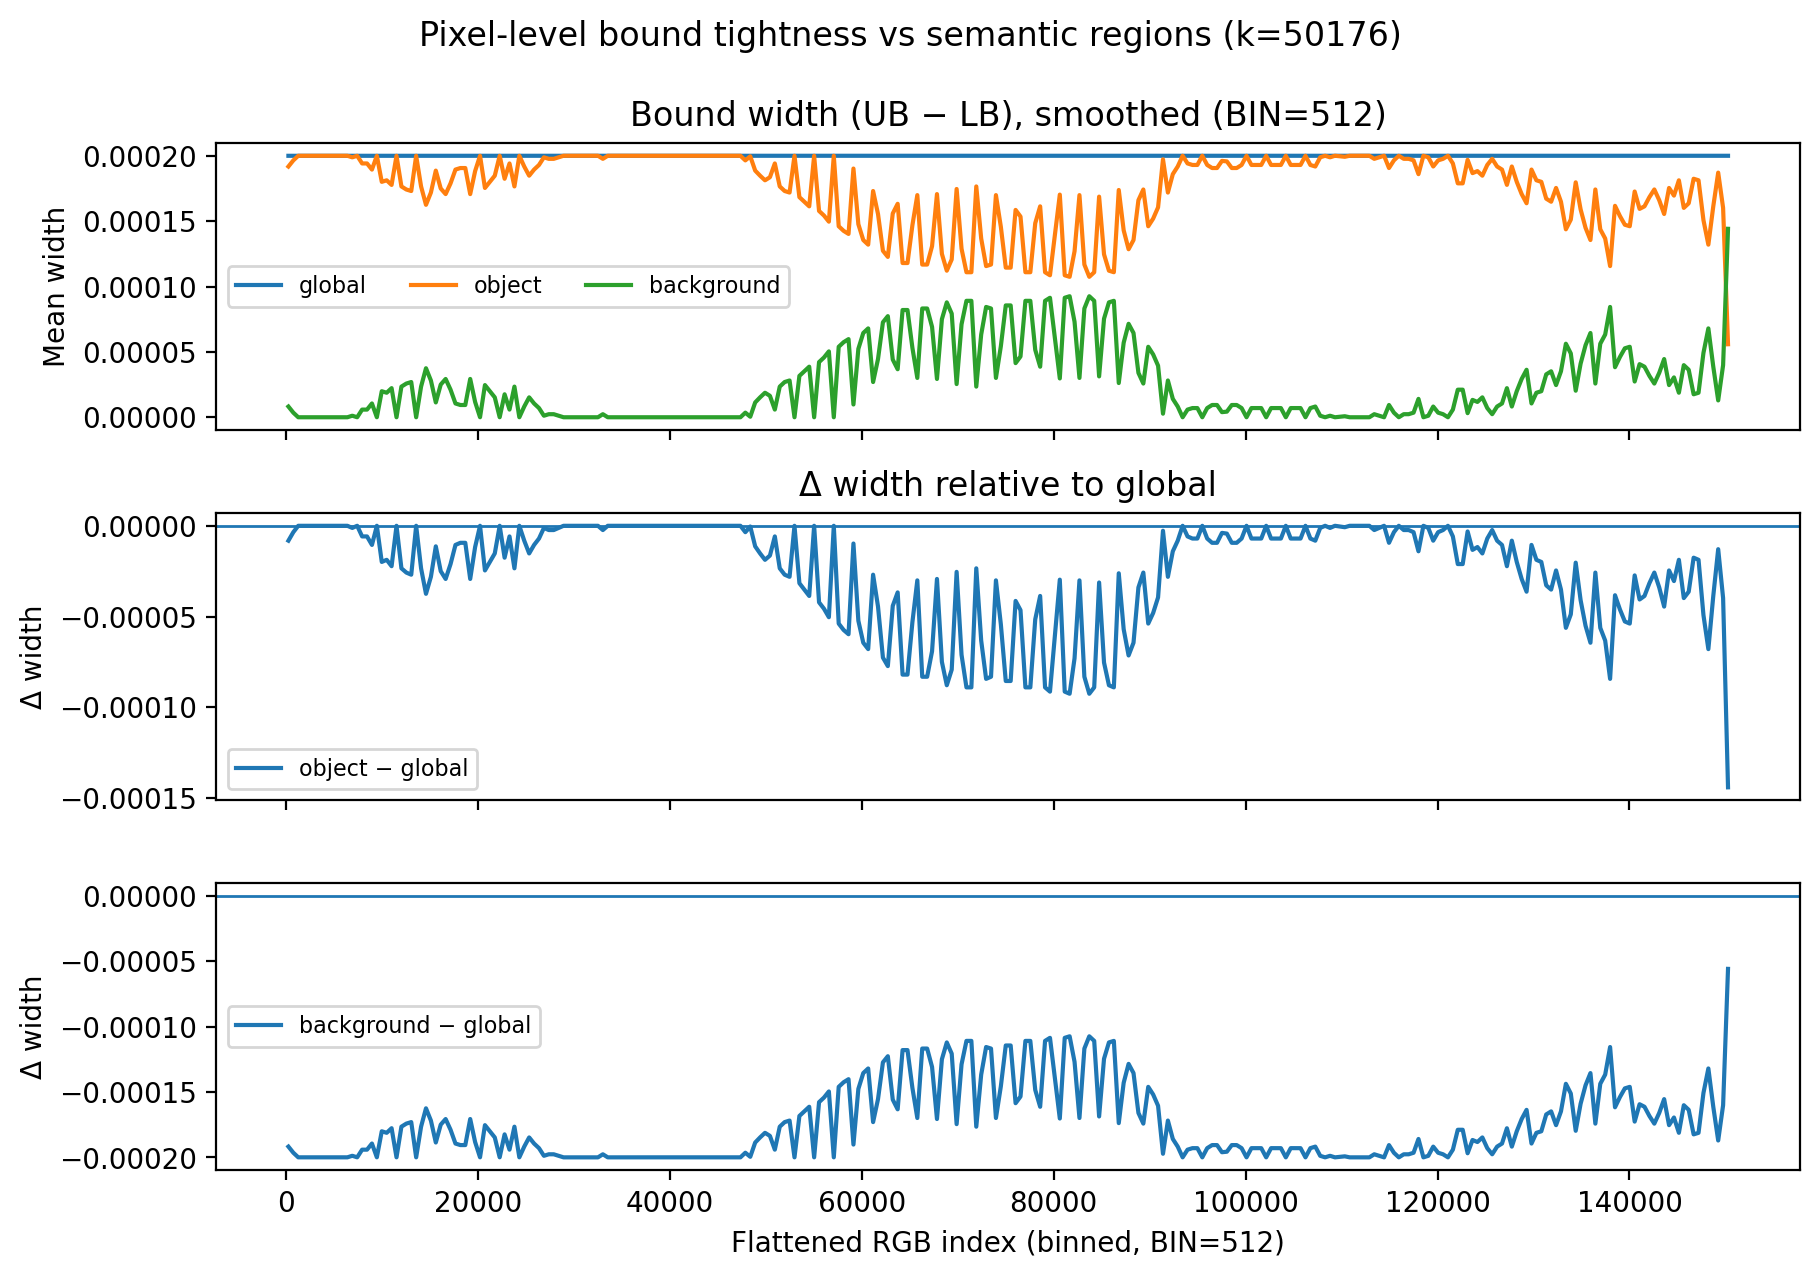

In [23]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

vnnlib_dir = Path("../benchmarks/vggnet16_benchmark2022_segmented_one_img_k/vnnlib_tmp")
K_TARGET = 50176
BIN = 512  # smoothing along flattened RGB index

# --- Parse vnnlib bounds ---
num = r"([+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?)"
re_le = re.compile(rf"\(<=\s+X_(\d+)\s+{num}\)")  # UB
re_ge = re.compile(rf"\(>=\s+X_(\d+)\s+{num}\)")  # LB
re_k  = re.compile(r"_k(\d+)_", re.IGNORECASE)

def category_from_name(name: str) -> str:
    n = name.lower()

    # Robust: allow fix_mask / fixmask / fix-nonmask etc.
    def has(patterns):
        return any(p in n for p in patterns)

    if "_global_" in n:
        return "global"

    # your screenshot: fix_mask and fix_nonmask
    if has(["_fix_mask_", "_fixmask_", "_fix-mask_"]):
        return "background"

    if has(["_fix_nonmask_", "_fixnonmask_", "_fix-nonmask_"]):
        return "object"

    return "unknown"

def parse_bounds_per_var(path: Path):
    lb, ub = {}, {}
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            m = re_ge.search(line)
            if m:
                i = int(m.group(1))
                lb[i] = float(m.group(2))
                continue
            m = re_le.search(line)
            if m:
                i = int(m.group(1))
                ub[i] = float(m.group(2))
                continue
    return lb, ub

# ----------------------------
# 1) Collect files for k=50176
# ----------------------------
files = []
for f in sorted(vnnlib_dir.glob("*.vnnlib")):
    km = re_k.search(f.name)
    if not km:
        continue
    if int(km.group(1)) != K_TARGET:
        continue
    cat = category_from_name(f.name)
    files.append((f, cat))

df_files = pd.DataFrame([{"file": f.name, "category": cat} for f, cat in files])
print("File counts by category:")
print(df_files["category"].value_counts(dropna=False).to_string())

# If everything lands in one category, you’ll see it here.
# You should have something like 10 global, 10 object, 10 background (or similar).

# Keep only known categories
files = [(f, cat) for (f, cat) in files if cat in ["global", "object", "background"]]
if not files:
    raise RuntimeError("No files in global/object/background after category parsing.")

# ----------------------------
# 2) Determine N (max X_i + 1)
# ----------------------------
max_idx = -1
for f, _cat in files:
    lb, ub = parse_bounds_per_var(f)
    if lb:
        max_idx = max(max_idx, max(lb.keys()))
    if ub:
        max_idx = max(max_idx, max(ub.keys()))
if max_idx < 0:
    raise RuntimeError("No X_i bounds parsed from any file.")
N = max_idx + 1
print(f"Detected N={N} (you said it’s 150528, good).")

# ----------------------------
# 3) Per-category mean LB/UB per index across files
# ----------------------------
cats = ["global", "object", "background"]
sum_lb = {c: np.zeros(N, dtype=np.float64) for c in cats}
sum_ub = {c: np.zeros(N, dtype=np.float64) for c in cats}
cnt_lb = {c: np.zeros(N, dtype=np.int32) for c in cats}
cnt_ub = {c: np.zeros(N, dtype=np.int32) for c in cats}

for f, cat in files:
    lb_dict, ub_dict = parse_bounds_per_var(f)

    if lb_dict:
        idx = np.fromiter(lb_dict.keys(), dtype=np.int64)
        vals = np.fromiter(lb_dict.values(), dtype=np.float64)
        sum_lb[cat][idx] += vals
        cnt_lb[cat][idx] += 1

    if ub_dict:
        idx = np.fromiter(ub_dict.keys(), dtype=np.int64)
        vals = np.fromiter(ub_dict.values(), dtype=np.float64)
        sum_ub[cat][idx] += vals
        cnt_ub[cat][idx] += 1

mean_lb = {c: np.divide(sum_lb[c], cnt_lb[c], out=np.full(N, np.nan), where=(cnt_lb[c] > 0)) for c in cats}
mean_ub = {c: np.divide(sum_ub[c], cnt_ub[c], out=np.full(N, np.nan), where=(cnt_ub[c] > 0)) for c in cats}

# Quick numeric check: if everything overlaps, these diffs will be ~0
for c1, c2 in [("global", "object"), ("global", "background"), ("object", "background")]:
    d = np.nanmean(np.abs(mean_ub[c1] - mean_ub[c2]))
    print(f"mean |UB({c1})-UB({c2})| = {d:.6g}")

# ----------------------------
# 4) Smooth by binning
# ----------------------------
x = np.arange(N, dtype=np.int64)
bin_id = x // BIN
n_bins = int(bin_id.max() + 1)
bin_centers = np.arange(n_bins) * BIN + BIN / 2.0

def binned_nanmean(arr):
    out = np.full(n_bins, np.nan, dtype=np.float64)
    for b in range(n_bins):
        vals = arr[bin_id == b]
        if np.isfinite(vals).any():
            out[b] = np.nanmean(vals)
    return out

smooth_lb = {c: binned_nanmean(mean_lb[c]) for c in cats}
smooth_ub = {c: binned_nanmean(mean_ub[c]) for c in cats}

# smooth_lb, smooth_ub already computed as dicts with keys: global/object/background
# bin_centers already computed
# BIN already defined

# 1) widths
w = {c: (smooth_ub[c] - smooth_lb[c]) for c in ["global", "object", "background"]}

# 2) differences vs global width
dw_obj = w["object"] - w["global"]
dw_bg  = w["background"] - w["global"]

fig, axes = plt.subplots(3, 1, figsize=(9.2, 6.4), dpi=200, sharex=True)

# Panel 1: widths (tightness)
axes[0].plot(bin_centers, w["global"], label="global")
axes[0].plot(bin_centers, w["object"], label="object")
axes[0].plot(bin_centers, w["background"], label="background")
axes[0].set_title(f"Bound width (UB − LB), smoothed (BIN={BIN})")
axes[0].set_ylabel("Mean width")
axes[0].legend(ncol=3, fontsize=8, frameon=True)

# Panel 2: Δwidth vs global (object)
axes[1].plot(bin_centers, dw_obj, label="object − global")
axes[1].axhline(0.0, linewidth=1)  # baseline
axes[1].set_title("Δ width relative to global")
axes[1].set_ylabel("Δ width")
axes[1].legend(fontsize=8, frameon=True)

# Panel 3: Δwidth vs global (background)
axes[2].plot(bin_centers, dw_bg, label="background − global")
axes[2].axhline(0.0, linewidth=1)  # baseline
axes[2].set_ylabel("Δ width")
axes[2].legend(fontsize=8, frameon=True)
axes[2].set_xlabel(f"Flattened RGB index (binned, BIN={BIN})")

fig.suptitle("Pixel-level bound tightness vs semantic regions (k=50176)", y=0.99)
plt.tight_layout()
plt.show()

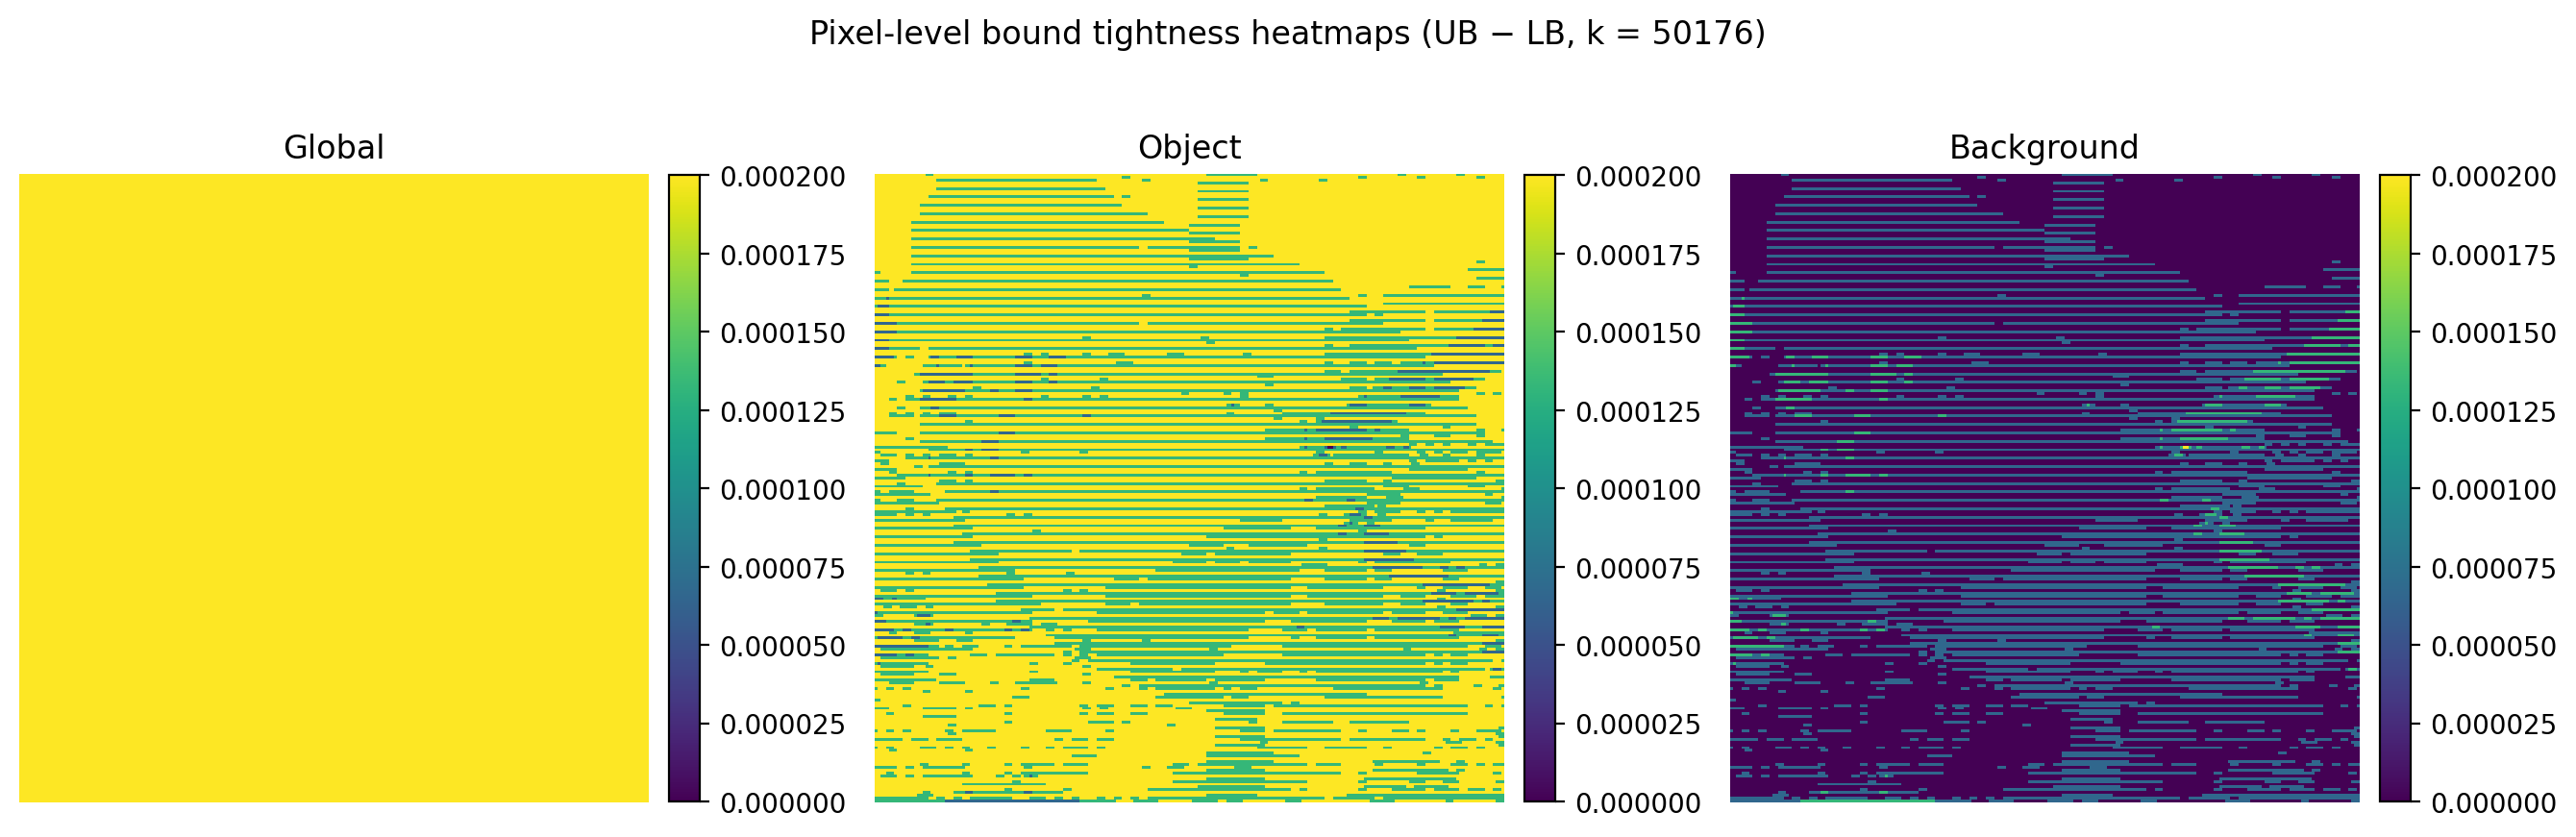

In [26]:
import numpy as np
import matplotlib.pyplot as plt

cats = ["global", "object", "background"]

# -------------------------------------------------
# 1) Compute widths
# -------------------------------------------------
width = {c: (mean_ub[c] - mean_lb[c]) for c in cats}
N = len(width["global"])

# -------------------------------------------------
# 2) Infer H,W,C (expect 224x224x3)
# -------------------------------------------------
if N == 224 * 224 * 3:
    H, W, C = 224, 224, 3
else:
    raise RuntimeError(f"Unexpected N={N}, expected 150528")

# -------------------------------------------------
# 3) Reshape + reduce channels
# -------------------------------------------------
ORDER = "CHW"     # change to "HWC" if it looks scrambled
REDUCE = "mean"   # mean over RGB

def vec_to_hw(vec):
    vec = np.asarray(vec)
    if ORDER == "CHW":
        x = vec.reshape(C, H, W)
        return np.nanmean(x, axis=0)
    else:  # HWC
        x = vec.reshape(H, W, C)
        return np.nanmean(x, axis=2)

maps = {
    "Global": vec_to_hw(width["global"]),
    "Object": vec_to_hw(width["object"]),
    "Background": vec_to_hw(width["background"]),
}

# -------------------------------------------------
# 4) Shared color scale for fair comparison
# -------------------------------------------------
vmin = min(np.nanmin(m) for m in maps.values())
vmax = max(np.nanmax(m) for m in maps.values())

# -------------------------------------------------
# 5) Plot 3 heatmaps
# -------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4), dpi=200)

for ax, (title, mat) in zip(axes, maps.items()):
    im = ax.imshow(mat, vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)

plt.suptitle("Pixel-level bound tightness heatmaps (UB − LB, k = 50176)", y=1.02)
plt.tight_layout()
plt.show()

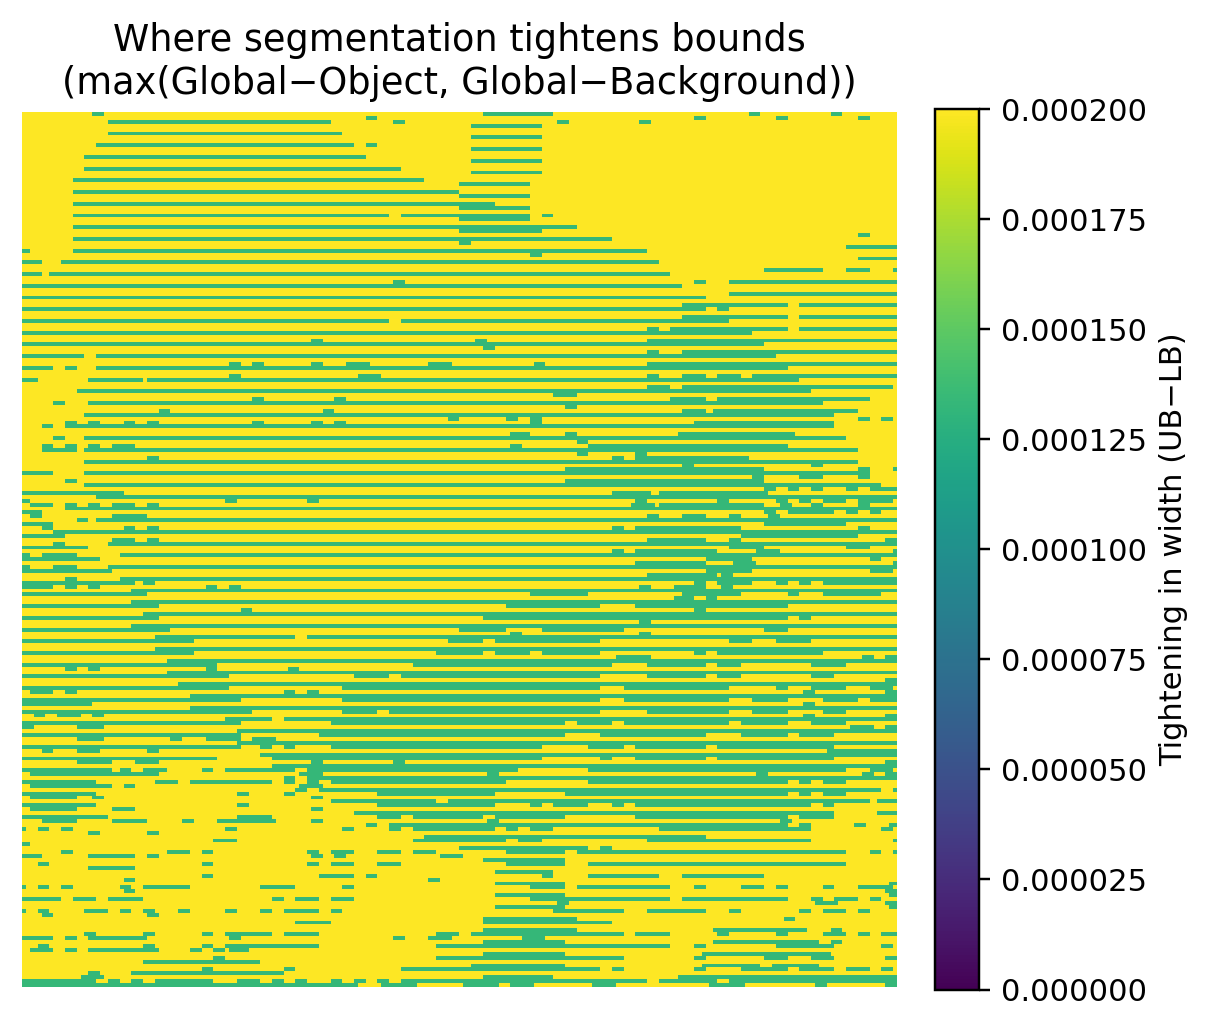

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# widths (2D): wG, wO, wB
# w = UB - LB

# improvement (tightening) = how much smaller than global
imp_obj = np.maximum(0.0, wG - wO)
imp_bg  = np.maximum(0.0, wG - wB)

# best tightening available from segmentation at each pixel
imp = np.maximum(imp_obj, imp_bg)

# robust scale so a few spikes don't ruin contrast
vmax = np.nanpercentile(imp, 99.0)

plt.figure(figsize=(5.6, 5.6), dpi=220)
im = plt.imshow(imp, vmin=0.0, vmax=vmax, interpolation="nearest")
plt.title("Where segmentation tightens bounds\n(max(Global−Object, Global−Background))")
plt.axis("off")
plt.colorbar(im, fraction=0.046, pad=0.04, label="Tightening in width (UB−LB)")
plt.tight_layout()
plt.show()

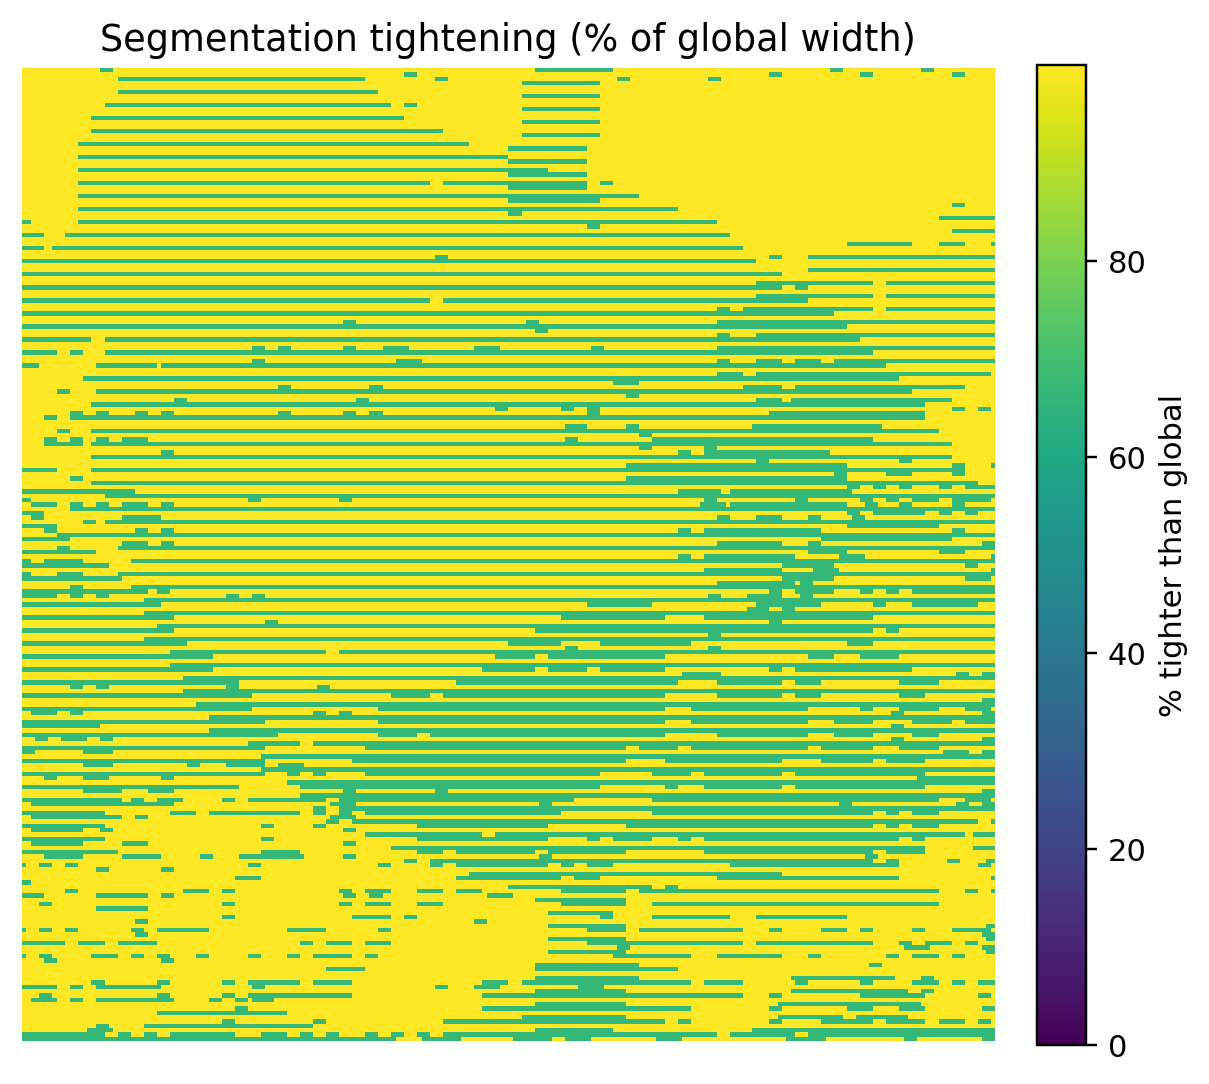

In [31]:
eps = 1e-12  # avoid divide by zero
pct_obj = 100.0 * (wG - wO) / (np.abs(wG) + eps)
pct_bg  = 100.0 * (wG - wB) / (np.abs(wG) + eps)

pct_obj = np.maximum(0.0, pct_obj)
pct_bg  = np.maximum(0.0, pct_bg)

pct = np.maximum(pct_obj, pct_bg)

vmax = np.nanpercentile(pct, 99.0)

plt.figure(figsize=(5.6, 5.6), dpi=220)
im = plt.imshow(pct, vmin=0.0, vmax=vmax, interpolation="nearest")
plt.title("Segmentation tightening (% of global width)")
plt.axis("off")
plt.colorbar(im, fraction=0.046, pad=0.04, label="% tighter than global")
plt.tight_layout()
plt.show()

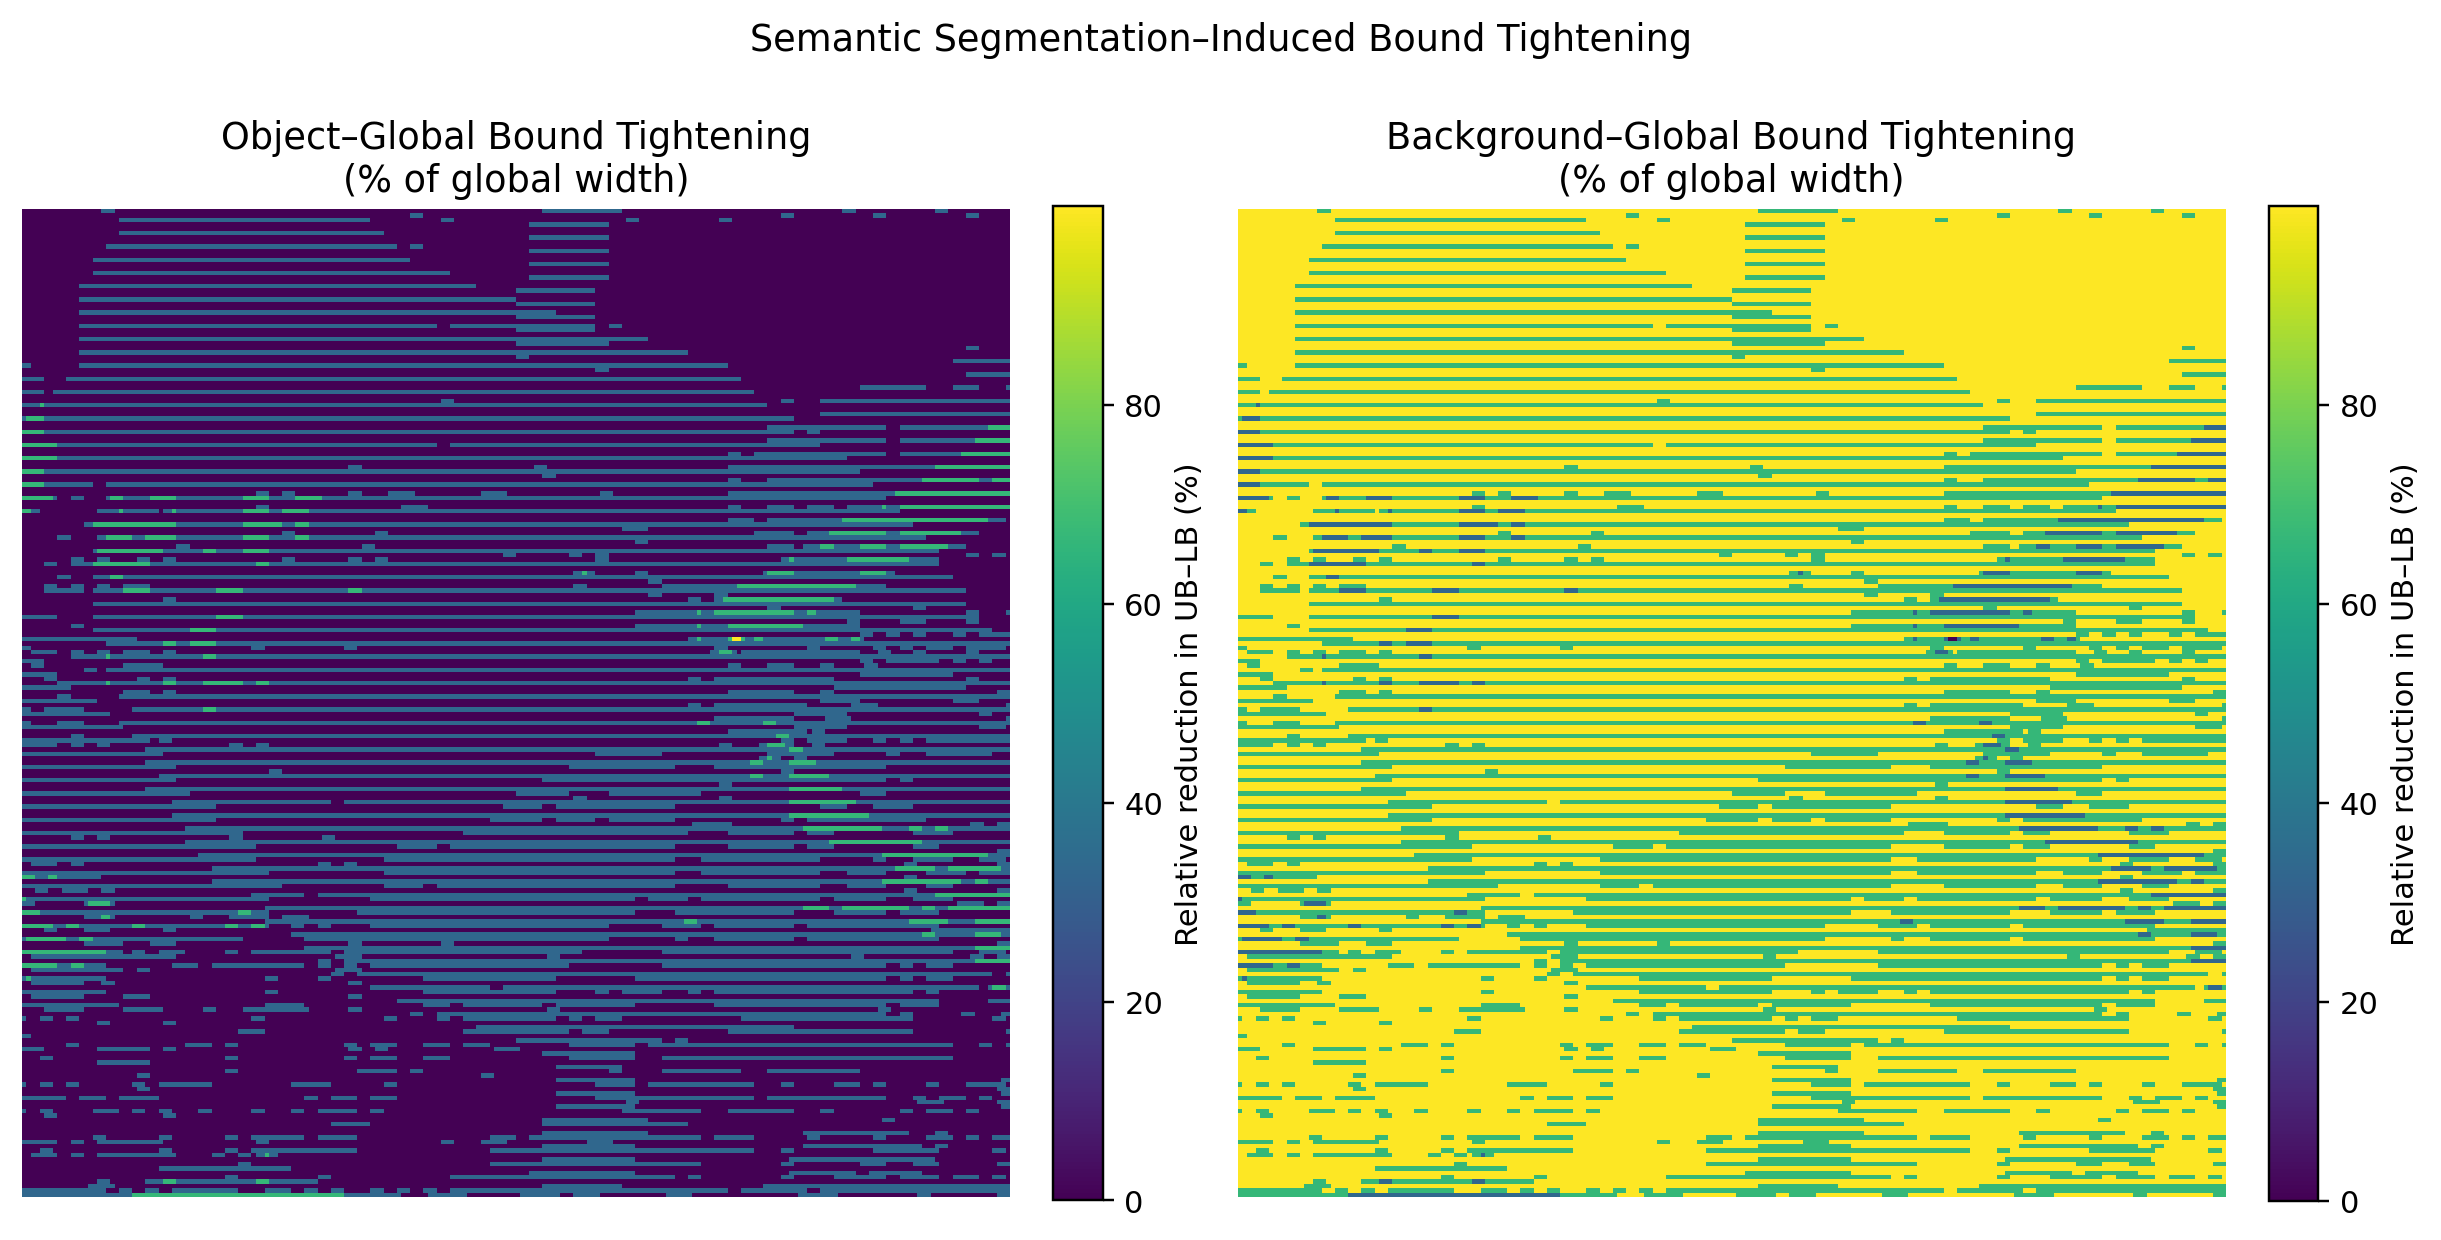

In [34]:
eps = 1e-12  # avoid divide by zero

# --- percent tightening relative to global ---
pct_obj = 100.0 * (wG - wO) / (np.abs(wG) + eps)
pct_bg  = 100.0 * (wG - wB) / (np.abs(wG) + eps)

# keep only tightening (positive improvements)
pct_obj = np.maximum(0.0, pct_obj)
pct_bg  = np.maximum(0.0, pct_bg)

# shared scale for comparison (robust to outliers)
vmax = np.nanpercentile(
    np.concatenate([pct_obj.ravel(), pct_bg.ravel()]),
    99.0,
)

# -------------------------------------------------
# Plot: two heatmaps
# -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11.2, 5.6), dpi=220)

# Object vs Global
im0 = axes[0].imshow(pct_obj, vmin=0.0, vmax=vmax, interpolation="nearest")
axes[0].set_title("Object–Global Bound Tightening\n(% of global width)")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04,
             label="Relative reduction in UB–LB (%)")

# Background vs Global
im1 = axes[1].imshow(pct_bg, vmin=0.0, vmax=vmax, interpolation="nearest")
axes[1].set_title("Background–Global Bound Tightening\n(% of global width)")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04,
             label="Relative reduction in UB–LB (%)")

plt.suptitle("Semantic Segmentation–Induced Bound Tightening", y=1.02)
plt.tight_layout()
plt.show()